In [1]:
# check kernel is pointing to HENS venv
import sys
print(sys.executable)

/home/ubuntu/projects/earth2studio/recipes/hens/.venv/bin/python3


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!pwd

/home/ubuntu/projects/earth2studio/recipes/hens/notebooks


In [37]:
ds = xr.open_mfdataset('../outputs_beryl_poc/houston/*.nc')

In [38]:
ds['w10m'] = np.sqrt(ds['u10m'] ** 2 + ds['v10m'] ** 2)

In [39]:
print(ds)

<xarray.Dataset> Size: 15MB
Dimensions:    (ensemble: 4, time: 16, lead_time: 9, lat: 41, lon: 41)
Coordinates:
  * ensemble   (ensemble) int64 32B 0 1 2 3
  * time       (time) datetime64[ns] 128B 2024-07-06 ... 2024-07-09T18:00:00
  * lead_time  (lead_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days 00:...
  * lat        (lat) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25.25 25.0
  * lon        (lon) float64 328B 260.0 260.2 260.5 260.8 ... 269.5 269.8 270.0
Data variables:
    u10m       (ensemble, time, lead_time, lat, lon) float32 4MB dask.array<chunksize=(4, 1, 9, 41, 41), meta=np.ndarray>
    v10m       (ensemble, time, lead_time, lat, lon) float32 4MB dask.array<chunksize=(4, 1, 9, 41, 41), meta=np.ndarray>
    msl        (ensemble, time, lead_time, lat, lon) float32 4MB dask.array<chunksize=(4, 1, 9, 41, 41), meta=np.ndarray>
    w10m       (ensemble, time, lead_time, lat, lon) float32 4MB dask.array<chunksize=(4, 1, 9, 41, 41), meta=np.ndarray>


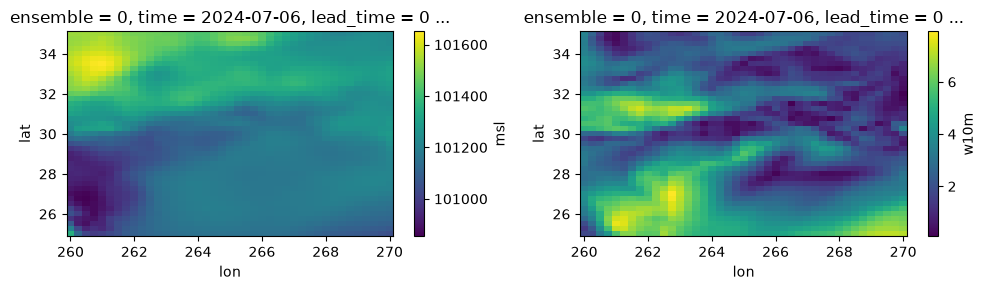

In [40]:
fig, ax = plt.subplots(1,2, figsize=(10,3))
ds['msl'].isel(ensemble=0, lead_time=0, time=0).plot(ax=ax[0])
ds['w10m'].isel(ensemble=0, lead_time=0, time=0).plot(ax=ax[1])
plt.tight_layout()

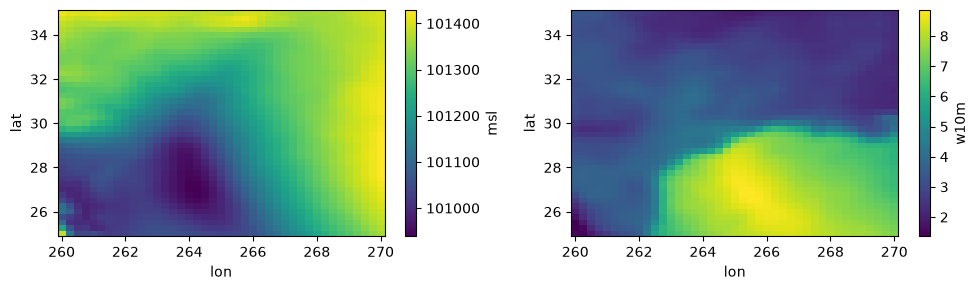

In [41]:
fig, ax = plt.subplots(1,2, figsize=(10,3))
ds['msl'].mean(['time', 'lead_time', 'ensemble']).plot(ax=ax[0])
ds['w10m'].mean(['time', 'lead_time', 'ensemble']).plot(ax=ax[1])
plt.tight_layout()

/tmp/ipykernel_64918/1578651775.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


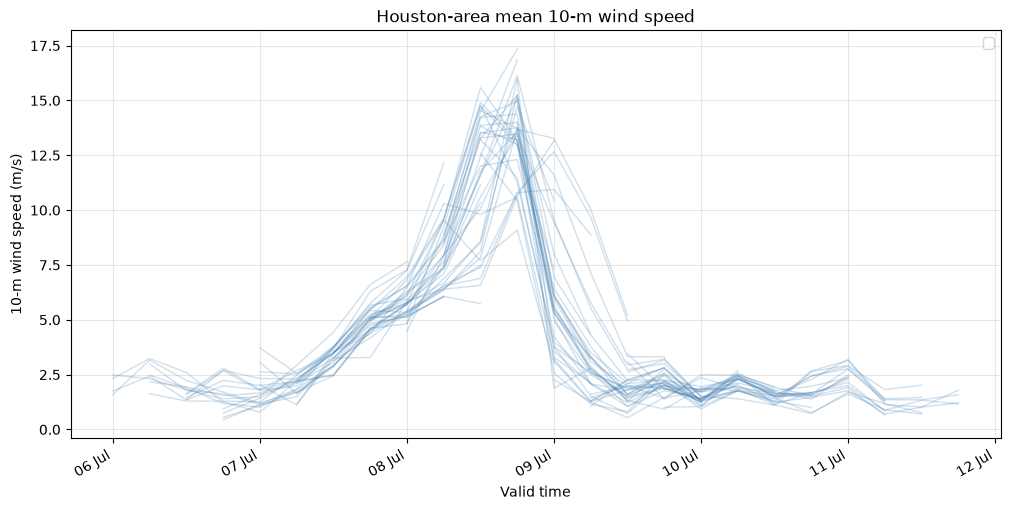

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

# Houston metro bounding box
lat_min, lat_max = 29.5, 30.1
lon_min, lon_max = 264.2, 265.0  # -95.8 to -95.0 in 0–360 coordinates

# Select the Houston region
houston = ds["w10m"].sel(
    lat=slice(lat_max, lat_min),  # latitude is descending
    lon=slice(lon_min, lon_max),
)

# Cosine-latitude weights for an area-weighted mean
weights = np.cos(np.deg2rad(houston.lat))

wind_mean = houston.weighted(weights).mean(dim=("lat", "lon")).compute()

# Plot each ensemble member and initialisation separately
fig, ax = plt.subplots(figsize=(12, 6))

for ensemble in wind_mean.ensemble.values:
    for init_time in wind_mean.time.values:

        wind_series = wind_mean.sel(
            ensemble=ensemble,
            time=init_time,
        )

        valid_time = init_time + wind_series.lead_time.values

        ax.plot(
            valid_time,
            wind_series.values,
            color="steelblue",
            alpha=0.25,
            linewidth=1,
        )

ax.set_xlabel("Valid time")
ax.set_ylabel("10-m wind speed (m/s)")
ax.set_title("Houston-area mean 10-m wind speed")
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.autofmt_xdate()

ax.legend()
plt.show()

In [14]:
track = xr.open_mfdataset('../outputs_beryl_poc/cyclones/*.nc')["__xarray_dataarray_variable__"]

/tmp/ipykernel_64918/648441200.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  track = xr.open_mfdataset('../outputs_beryl_poc/cyclones/*.nc')["__xarray_dataarray_variable__"]
/tmp/ipykernel_64918/648441200.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'path_id' ('path_id',) The recommendation is to set join explicitly for this case.
  track = xr.open_mfdataset('../outputs_beryl_poc/cyclones/*.nc')["__xarray_dataarray_v

In [15]:
track

<xarray.DataArray '__xarray_dataarray_variable__' (ensemble: 4, time: 16,
                                                   path_id: 18, step: 9,
                                                   variable: 4)> Size: 332kB
dask.array<concatenate, shape=(4, 16, 18, 9, 4), dtype=float64, chunksize=(2, 1, 5, 9, 4), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) int64 32B 0 1 2 3
  * time      (time) datetime64[ns] 128B 2024-07-06 ... 2024-07-09T18:00:00
  * path_id   (path_id) int64 144B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
  * step      (step) int64 72B 0 1 2 3 4 5 6 7 8
  * variable  (variable) <U6 96B 'tclat' 'tclon' 'tcmsl' 'tcw10m'

In [16]:
print(track)

<xarray.DataArray '__xarray_dataarray_variable__' (ensemble: 4, time: 16,
                                                   path_id: 18, step: 9,
                                                   variable: 4)> Size: 332kB
dask.array<concatenate, shape=(4, 16, 18, 9, 4), dtype=float64, chunksize=(2, 1, 5, 9, 4), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) int64 32B 0 1 2 3
  * time      (time) datetime64[ns] 128B 2024-07-06 ... 2024-07-09T18:00:00
  * path_id   (path_id) int64 144B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17
  * step      (step) int64 72B 0 1 2 3 4 5 6 7 8
  * variable  (variable) <U6 96B 'tclat' 'tclon' 'tcmsl' 'tcw10m'


(array([ 65., 185., 303., 258., 107., 158., 101.,  28.,   2.,   1.]),
 array([ 1.34649086,  4.65193691,  7.95738297, 11.26282902, 14.56827507,
        17.87372112, 21.17916718, 24.48461323, 27.79005928, 31.09550533,
        34.40095139]),
 <BarContainer object of 10 artists>)

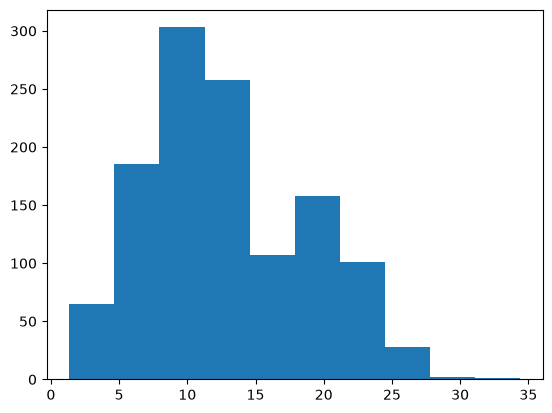

In [29]:
plt.hist(track.sel(variable="tcw10m").values.flatten())

(array([ 15.,  18.,  76., 223., 276., 242., 170., 118.,  66.,   4.]),
 array([ 97699.9375   ,  98162.7765625,  98625.615625 ,  99088.4546875,
         99551.29375  , 100014.1328125, 100476.971875 , 100939.8109375,
        101402.65     , 101865.4890625, 102328.328125 ]),
 <BarContainer object of 10 artists>)

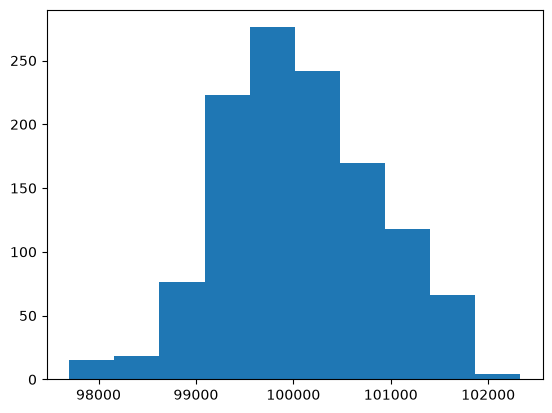

In [30]:
plt.hist(track.sel(variable="tcmsl").values.flatten())

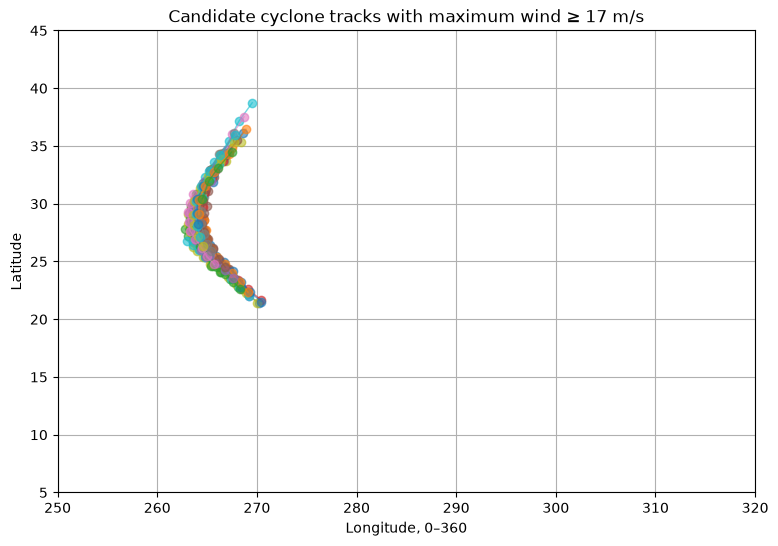

In [25]:
import numpy as np
import matplotlib.pyplot as plt

lat = track.sel(variable="tclat")
lon = track.sel(variable="tclon")
wind = track.sel(variable="tcw10m")
msl = track.sel(variable="tcmsl")

fig, ax = plt.subplots(figsize=(9, 6))

for ensemble in track.ensemble.values:
    for time in track.time.values:
        for path_id in track.path_id.values:

            x = np.asarray(
                lon.sel(ensemble=ensemble, time=time, path_id=path_id)
            ).squeeze()

            y = np.asarray(
                lat.sel(ensemble=ensemble, time=time, path_id=path_id)
            ).squeeze()

            w = np.asarray(
                wind.sel(ensemble=ensemble, time=time, path_id=path_id)
            ).squeeze()

            # Keep only paths that reach tropical-storm strength
            if not np.any(np.isfinite(w) & (w >= 17)):
                continue

            valid = np.isfinite(x) & np.isfinite(y)

            if np.count_nonzero(valid) >= 2:
                ax.plot(
                    x[valid],
                    y[valid],
                    marker="o",
                    linewidth=1,
                    alpha=0.6,
                )

ax.set_xlim(250, 320)
ax.set_ylim(5, 45)
ax.set_xlabel("Longitude, 0–360")
ax.set_ylabel("Latitude")
ax.set_title("Candidate cyclone tracks with maximum wind ≥ 17 m/s")
ax.grid(True)
plt.show()

/home/ubuntu/projects/earth2studio/recipes/hens/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ubuntu/projects/earth2studio/recipes/hens/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ubuntu/projects/earth2studio/recipes/hens/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/ubuntu/projects/earth2studio/recipes/hens/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_adm

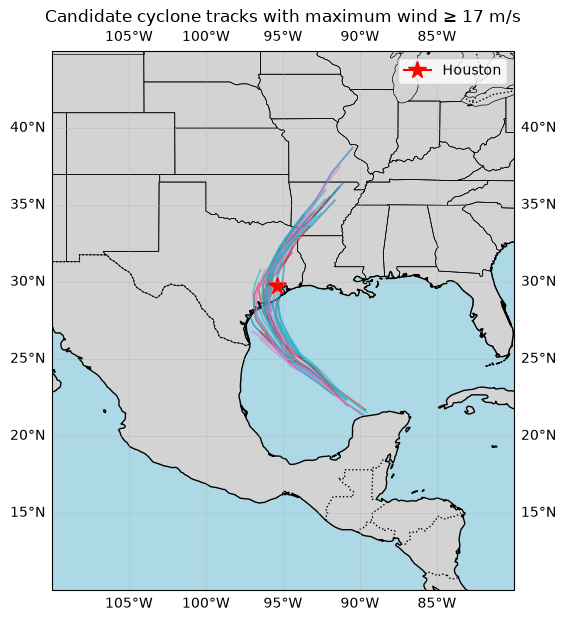

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lat = track.sel(variable="tclat")
lon = track.sel(variable="tclon")
wind = track.sel(variable="tcw10m")

projection = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={"projection": projection},
)

# Relevant map window only; this does not filter tracks
ax.set_extent([-110, -80, 10, 45], crs=projection)

ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linewidth=0.5)

colours = plt.cm.tab10(
    np.linspace(0, 1, len(track.ensemble.values))
)

for ensemble_idx, ensemble in enumerate(track.ensemble.values):
    for time in track.time.values:
        for path_id in track.path_id.values:

            x = np.asarray(
                lon.sel(
                    ensemble=ensemble,
                    time=time,
                    path_id=path_id,
                )
            ).squeeze()

            y = np.asarray(
                lat.sel(
                    ensemble=ensemble,
                    time=time,
                    path_id=path_id,
                )
            ).squeeze()

            w = np.asarray(
                wind.sel(
                    ensemble=ensemble,
                    time=time,
                    path_id=path_id,
                )
            ).squeeze()

            # Apply only the wind filter
            if not np.any(np.isfinite(w) & (w >= 17)):
                continue

            valid = np.isfinite(x) & np.isfinite(y)

            if np.count_nonzero(valid) < 2:
                continue

            # Convert 0–360 longitude to -180–180
            x = ((x + 180) % 360) - 180

            ax.plot(
                x[valid],
                y[valid],
                color=colours[ensemble_idx],
                linewidth=1.3,
                alpha=0.6,
                transform=projection,
            )

# Houston
ax.plot(
    -95.37,
    29.76,
    marker="s",
    color="red",
    markersize=13,
    transform=projection,
    label="Houston",
)

ax.set_title("Candidate cyclone tracks with maximum wind ≥ 17 m/s")
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax.legend()

plt.show()